# Sandeep Parupalli  
## Advanced Big Data and Data Mining (MSCS-634-B01)  
### Lab 4: Regression Techniques and Regularization on the Diabetes Dataset  
**Instructor:** Satish Penmatsa  
**University of the Cumberlands**  
**GitHub Repository:** https://github.com/Sandeep271/Lab-4-Regression-Analysis-with-Regularization-Techniques

---

## Lab Overview
In this lab, I explored several regression techniques using the Diabetes dataset from `sklearn.datasets`. The purpose of the work was to compare how different regression models behave on the same prediction task and to understand how regularization can improve generalization and reduce overfitting.

### Models covered
- Simple Linear Regression
- Multiple Linear Regression
- Polynomial Regression
- Ridge Regression
- Lasso Regression

### Evaluation metrics
To compare model performance, I used:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R-squared (R²)

### Notebook goals
This notebook follows the lab requirements by:
1. Loading and exploring the Diabetes dataset
2. Building simple, multiple, and polynomial regression models
3. Applying Ridge and Lasso regularization
4. Comparing model performance with common regression metrics
5. Interpreting the results in clear, written analysis


In [1]:

# Standard data analysis and visualization libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn tools for loading data, preprocessing, modeling, and evaluation
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display settings for cleaner notebook output
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)


## Step 1: Data Preparation

The Diabetes dataset is a built-in dataset provided by scikit-learn. It contains ten baseline health-related variables and a quantitative target variable representing disease progression one year after baseline.

In this section, I:
1. Loaded the dataset
2. Converted it into a pandas DataFrame
3. Explored feature names, shape, and summary statistics
4. Checked for missing values
5. Examined the distribution of the target variable


In [2]:

# Load the diabetes dataset
diabetes = load_diabetes()

# Create a feature DataFrame and target Series
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name='disease_progression')

# Basic dataset inspection
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("\nFeature names:")
print(list(X.columns))

# Display the first few rows
X.head()


Feature matrix shape: (442, 10)
Target vector shape: (442,)

Feature names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.0381,0.0507,0.0617,0.0219,-0.0442,-0.0348,-0.0434,-0.0026,0.0199,-0.0176
1,-0.0019,-0.0446,-0.0515,-0.0263,-0.0084,-0.0192,0.0744,-0.0395,-0.0683,-0.0922
2,0.0853,0.0507,0.0445,-0.0057,-0.0456,-0.0342,-0.0324,-0.0026,0.0029,-0.0259
3,-0.0891,-0.0446,-0.0116,-0.0367,0.0122,0.0250,-0.0360,0.0343,0.0227,-0.0094
4,0.0054,-0.0446,-0.0364,0.0219,0.0039,0.0156,0.0081,-0.0026,-0.0320,-0.0466


In [3]:

# Combine features and target for easier analysis
df = X.copy()
df['disease_progression'] = y

# Summary statistics
display(df.describe().T)

# Check for missing values
missing_values = df.isnull().sum().to_frame(name='Missing Values')
display(missing_values)


,count,mean,std,min,25%,50%,75%,max
age,442.0000,-0.0000,0.0476,-0.1072,-0.0373,0.0054,0.0381,0.1107
sex,442.0000,0.0000,0.0476,-0.0446,-0.0446,-0.0446,0.0507,0.0507
bmi,442.0000,-0.0000,0.0476,-0.0903,-0.0342,-0.0073,0.0312,0.1706
bp,442.0000,-0.0000,0.0476,-0.1124,-0.0367,-0.0057,0.0356,0.1320
s1,442.0000,-0.0000,0.0476,-0.1268,-0.0342,-0.0043,0.0284,0.1539
s2,442.0000,0.0000,0.0476,-0.1156,-0.0304,-0.0038,0.0298,0.1988
s3,442.0000,-0.0000,0.0476,-0.1023,-0.0351,-0.0066,0.0293,0.1812
s4,442.0000,-0.0000,0.0476,-0.0764,-0.0395,-0.0026,0.0343,0.1852
s5,442.0000,0.0000,0.0476,-0.1261,-0.0332,-0.0019,0.0324,0.1336
s6,442.0000,0.0000,0.0476,-0.1378,-0.0332,-0.0011,0.0279,0.1356


,Missing Values
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


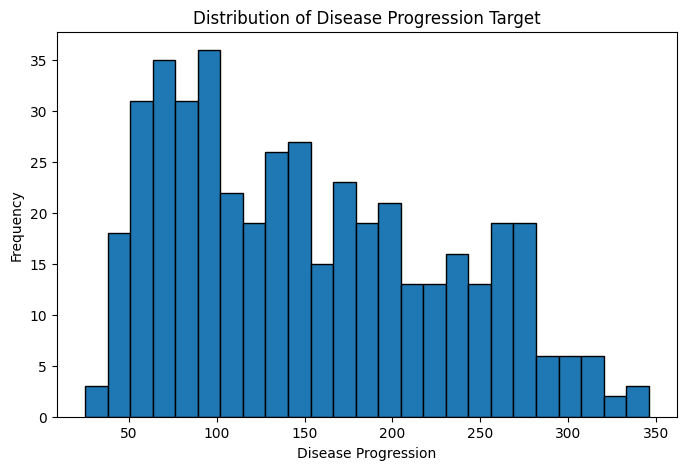

,Correlation with Target
bmi,0.5865
s5,0.5659
bp,0.4415
s4,0.4305
s3,-0.3948
s6,0.3825
s1,0.2120
age,0.1879
s2,0.1741
sex,0.0431


In [4]:

# Visualize the target distribution
plt.figure(figsize=(8, 5))
plt.hist(y, bins=25, edgecolor='black')
plt.title('Distribution of Disease Progression Target')
plt.xlabel('Disease Progression')
plt.ylabel('Frequency')
plt.show()

# Show feature correlations with the target
correlations = df.corr(numeric_only=True)['disease_progression'].drop('disease_progression').sort_values(key=lambda s: s.abs(), ascending=False)
display(correlations.to_frame(name='Correlation with Target'))


### Data Cleaning Notes
The dataset did not contain missing values, so no imputation or row removal was needed. Since the feature values in the Diabetes dataset are already standardized in scikit-learn, the data was already in a clean and analysis-ready format.  

For the simple linear regression section, I selected **BMI** as the single input feature because it had the strongest correlation with the target variable among all available features in this dataset.


In [5]:

# Helper function to calculate evaluation metrics
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R2': r2_score(y_true, y_pred)
    }

# Split once for a fair comparison across the models
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Separate split for the simple single-feature model using BMI
X_train_bmi = X_train_all[['bmi']]
X_test_bmi = X_test_all[['bmi']]


## Step 2: Simple Linear Regression

I first trained a simple linear regression model using only **BMI** as the independent variable. This provides a baseline and helps show how much predictive power can be obtained from a single feature alone.


In [6]:

# Train a simple linear regression model using BMI only
simple_lr = LinearRegression()
simple_lr.fit(X_train_bmi, y_train)

# Make predictions
simple_train_pred = simple_lr.predict(X_train_bmi)
simple_test_pred = simple_lr.predict(X_test_bmi)

# Evaluate the model
simple_train_metrics = regression_metrics(y_train, simple_train_pred)
simple_test_metrics = regression_metrics(y_test, simple_test_pred)

simple_results = pd.DataFrame([simple_train_metrics, simple_test_metrics], index=['Train', 'Test'])
display(simple_results)

print("Simple Linear Regression coefficient:", round(simple_lr.coef_[0], 4))
print("Simple Linear Regression intercept:", round(simple_lr.intercept_, 4))


,MAE,MSE,RMSE,R2
Train,51.3797,"3,854.1127",62.0815,0.3657
Test,52.2600,"4,061.8259",63.7325,0.2334


Simple Linear Regression coefficient: 998.5777
Simple Linear Regression intercept: 152.0034


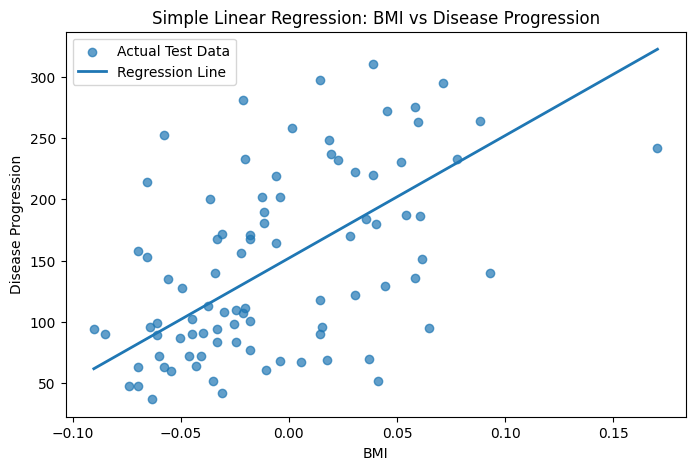

In [7]:

# Plot actual data points and fitted regression line on the test set
sorted_idx = np.argsort(X_test_bmi['bmi'].values)
x_sorted = X_test_bmi['bmi'].values[sorted_idx]
y_pred_sorted = simple_test_pred[sorted_idx]

plt.figure(figsize=(8, 5))
plt.scatter(X_test_bmi['bmi'], y_test, alpha=0.7, label='Actual Test Data')
plt.plot(x_sorted, y_pred_sorted, linewidth=2, label='Regression Line')
plt.title('Simple Linear Regression: BMI vs Disease Progression')
plt.xlabel('BMI')
plt.ylabel('Disease Progression')
plt.legend()
plt.show()


## Step 3: Multiple Linear Regression

Next, I trained a multiple linear regression model using **all ten input features**. This model uses more information than the simple linear model and should capture the target more effectively.


In [8]:

# Train multiple linear regression using all features
multiple_lr = LinearRegression()
multiple_lr.fit(X_train_all, y_train)

# Predict and evaluate
multiple_train_pred = multiple_lr.predict(X_train_all)
multiple_test_pred = multiple_lr.predict(X_test_all)

multiple_train_metrics = regression_metrics(y_train, multiple_train_pred)
multiple_test_metrics = regression_metrics(y_test, multiple_test_pred)

multiple_results = pd.DataFrame([multiple_train_metrics, multiple_test_metrics], index=['Train', 'Test'])
display(multiple_results)

# Review coefficients
coef_table = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': multiple_lr.coef_
}).sort_values(by='Coefficient', key=lambda s: s.abs(), ascending=False)

display(coef_table.reset_index(drop=True))


,MAE,MSE,RMSE,R2
Train,43.4835,"2,868.5497",53.5588,0.5279
Test,42.7941,"2,900.1936",53.8534,0.4526


,Feature,Coefficient
0,s1,-931.4888
1,s5,736.1989
2,bmi,542.4288
3,s2,518.0623
4,bp,347.7038
5,s4,275.3179
6,sex,-241.9644
7,s3,163.4200
8,s6,48.6707
9,age,37.9040


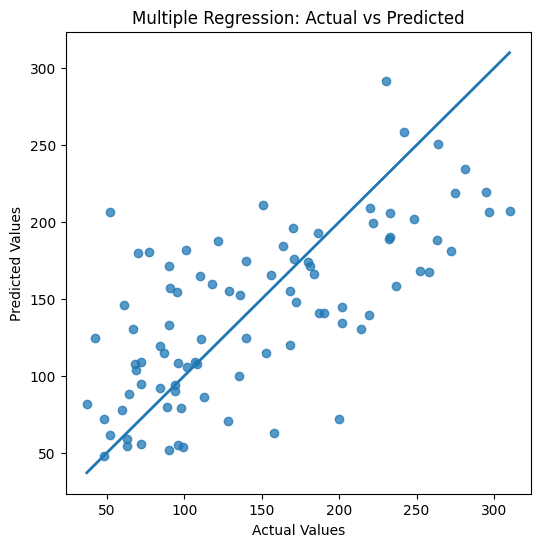

In [9]:

# Predicted vs actual plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, multiple_test_pred, alpha=0.75)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linewidth=2)
plt.title('Multiple Regression: Actual vs Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()


## Step 4: Polynomial Regression

Polynomial regression extends a linear model by adding interaction terms and higher-order terms. This can help capture more complex relationships, but it can also lead to overfitting if the polynomial degree becomes too large.

To demonstrate this, I used all features and compared:
- Degree 2 polynomial regression
- Degree 3 polynomial regression

This comparison makes it easier to observe how model complexity affects both training and testing performance.


In [10]:

poly_summary = []

for degree in [2, 3]:
    poly_model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('linear', LinearRegression())
    ])

    poly_model.fit(X_train_all, y_train)

    train_pred = poly_model.predict(X_train_all)
    test_pred = poly_model.predict(X_test_all)

    train_metrics = regression_metrics(y_train, train_pred)
    test_metrics = regression_metrics(y_test, test_pred)

    poly_summary.append({
        'Model': f'Polynomial Degree {degree}',
        'Train MAE': train_metrics['MAE'],
        'Train MSE': train_metrics['MSE'],
        'Train RMSE': train_metrics['RMSE'],
        'Train R2': train_metrics['R2'],
        'Test MAE': test_metrics['MAE'],
        'Test MSE': test_metrics['MSE'],
        'Test RMSE': test_metrics['RMSE'],
        'Test R2': test_metrics['R2']
    })

poly_results = pd.DataFrame(poly_summary)
display(poly_results)


,Model,Train MAE,Train MSE,Train RMSE,Train R2,Test MAE,Test MSE,Test RMSE,Test R2
0,Polynomial Degree 2,39.1426,"2,393.1386",48.9197,0.6062,43.5817,"3,096.0283",55.6420,0.4156
1,Polynomial Degree 3,18.6890,745.6184,27.3060,0.8773,164.8539,"82,446.0479",287.1342,-14.5613


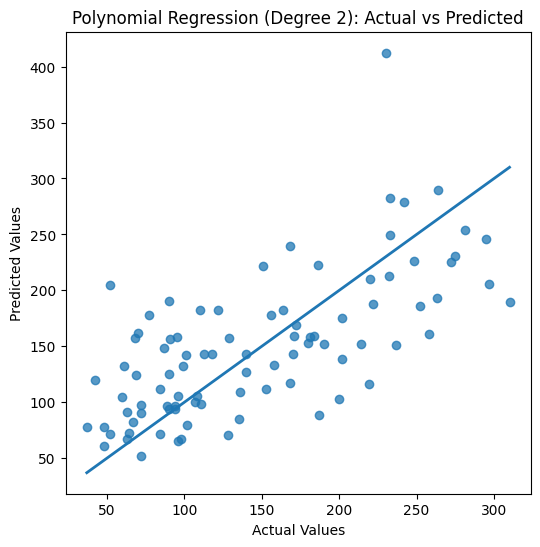

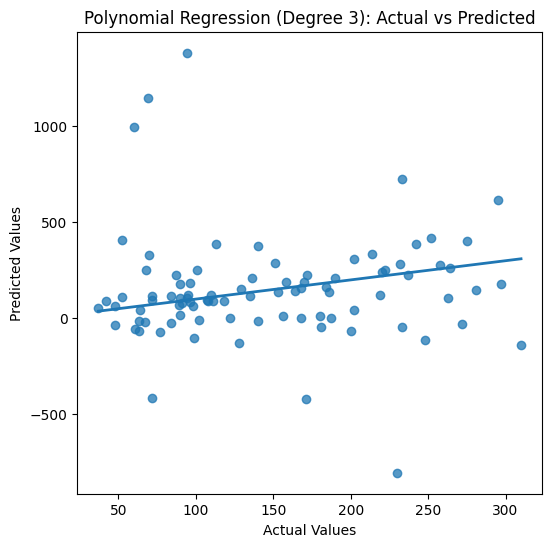

In [11]:

# Fit degree-2 and degree-3 models again for plotting actual vs predicted
poly_deg2 = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('linear', LinearRegression())
])

poly_deg3 = Pipeline([
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('linear', LinearRegression())
])

poly_deg2.fit(X_train_all, y_train)
poly_deg3.fit(X_train_all, y_train)

poly_deg2_pred = poly_deg2.predict(X_test_all)
poly_deg3_pred = poly_deg3.predict(X_test_all)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, poly_deg2_pred, alpha=0.75)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linewidth=2)
plt.title('Polynomial Regression (Degree 2): Actual vs Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, poly_deg3_pred, alpha=0.75)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linewidth=2)
plt.title('Polynomial Regression (Degree 3): Actual vs Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()


### Polynomial Regression Observation
The degree 2 model added more flexibility, but the degree 3 model became too complex for this small dataset. It achieved a much better fit on the training data, but its testing error increased dramatically. This is a clear example of **overfitting**: the model learned the training data too closely and did not generalize well to unseen data.


## Step 5: Regularization with Ridge and Lasso Regression

Regularization helps control model complexity by shrinking coefficient values. This can improve stability and reduce overfitting.

- **Ridge Regression** shrinks coefficients toward zero but usually keeps all variables in the model.
- **Lasso Regression** can shrink some coefficients all the way to zero, which also performs feature selection.

Because Ridge and Lasso are sensitive to feature scale, I used `StandardScaler` before each regularized model.


In [12]:

alpha_values = [0.01, 0.1, 1.0, 10.0, 100.0]

ridge_rows = []
lasso_rows = []

for alpha in alpha_values:
    ridge_model = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])
    ridge_model.fit(X_train_all, y_train)
    ridge_pred = ridge_model.predict(X_test_all)
    ridge_metrics = regression_metrics(y_test, ridge_pred)

    ridge_rows.append({
        'Alpha': alpha,
        'MAE': ridge_metrics['MAE'],
        'MSE': ridge_metrics['MSE'],
        'RMSE': ridge_metrics['RMSE'],
        'R2': ridge_metrics['R2']
    })

    lasso_model = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=alpha, max_iter=10000))
    ])
    lasso_model.fit(X_train_all, y_train)
    lasso_pred = lasso_model.predict(X_test_all)
    lasso_metrics = regression_metrics(y_test, lasso_pred)
    nonzero_count = np.sum(lasso_model.named_steps['lasso'].coef_ != 0)

    lasso_rows.append({
        'Alpha': alpha,
        'MAE': lasso_metrics['MAE'],
        'MSE': lasso_metrics['MSE'],
        'RMSE': lasso_metrics['RMSE'],
        'R2': lasso_metrics['R2'],
        'Non-zero Coefficients': nonzero_count
    })

ridge_results = pd.DataFrame(ridge_rows)
lasso_results = pd.DataFrame(lasso_rows)

print("Ridge Regression Results")
display(ridge_results)

print("Lasso Regression Results")
display(lasso_results)


Ridge Regression Results


,Alpha,MAE,MSE,RMSE,R2
0,0.0100,42.7942,"2,900.0751",53.8523,0.4526
1,0.1000,42.7962,"2,899.0546",53.8429,0.4528
2,1.0000,42.8120,"2,892.0146",53.7775,0.4541
3,10.0000,42.8568,"2,875.7787",53.6263,0.4572
4,100.0000,43.2507,"2,858.2243",53.4624,0.4605


Lasso Regression Results


,Alpha,MAE,MSE,RMSE,R2,Non-zero Coefficients
0,0.0100,42.7950,"2,898.3680",53.8365,0.4529,10
1,0.1000,42.8052,"2,884.6243",53.7087,0.4555,10
2,1.0000,42.8030,"2,824.5681",53.1467,0.4669,9
3,10.0000,44.7646,"2,933.8347",54.1649,0.4463,4
4,100.0000,64.0065,"5,361.5335",73.2225,-0.0120,0


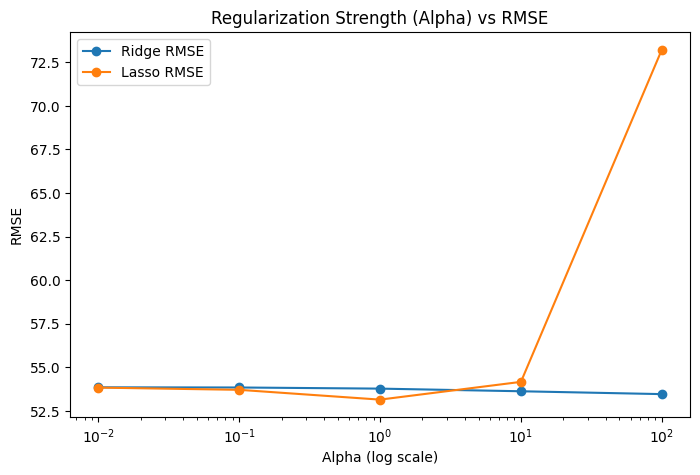

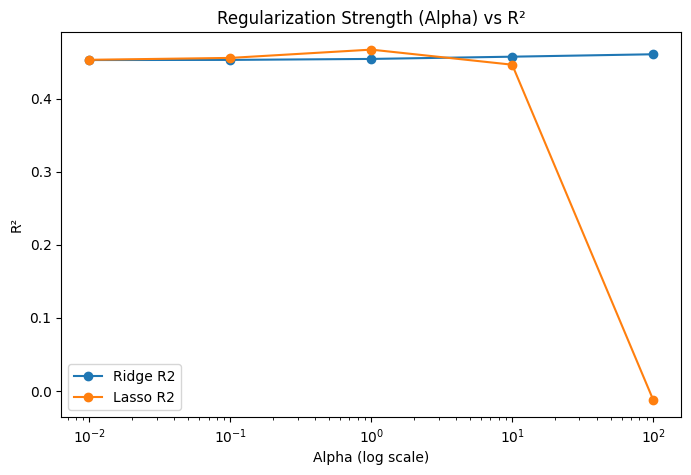

In [13]:

# Plot alpha vs RMSE for Ridge and Lasso
plt.figure(figsize=(8, 5))
plt.plot(ridge_results['Alpha'], ridge_results['RMSE'], marker='o', label='Ridge RMSE')
plt.plot(lasso_results['Alpha'], lasso_results['RMSE'], marker='o', label='Lasso RMSE')
plt.xscale('log')
plt.title('Regularization Strength (Alpha) vs RMSE')
plt.xlabel('Alpha (log scale)')
plt.ylabel('RMSE')
plt.legend()
plt.show()

# Plot alpha vs R2 for Ridge and Lasso
plt.figure(figsize=(8, 5))
plt.plot(ridge_results['Alpha'], ridge_results['R2'], marker='o', label='Ridge R2')
plt.plot(lasso_results['Alpha'], lasso_results['R2'], marker='o', label='Lasso R2')
plt.xscale('log')
plt.title('Regularization Strength (Alpha) vs R²')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R²')
plt.legend()
plt.show()


In [14]:

# Select the best Ridge and best Lasso models based on test RMSE
best_ridge_alpha = ridge_results.loc[ridge_results['RMSE'].idxmin(), 'Alpha']
best_lasso_alpha = lasso_results.loc[lasso_results['RMSE'].idxmin(), 'Alpha']

best_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=best_ridge_alpha))
])

best_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=best_lasso_alpha, max_iter=10000))
])

best_ridge.fit(X_train_all, y_train)
best_lasso.fit(X_train_all, y_train)

best_ridge_pred = best_ridge.predict(X_test_all)
best_lasso_pred = best_lasso.predict(X_test_all)

print(f"Best Ridge alpha: {best_ridge_alpha}")
print(f"Best Lasso alpha: {best_lasso_alpha}")

ridge_coef = pd.DataFrame({
    'Feature': X.columns,
    'Ridge Coefficient': best_ridge.named_steps['ridge'].coef_
})

lasso_coef = pd.DataFrame({
    'Feature': X.columns,
    'Lasso Coefficient': best_lasso.named_steps['lasso'].coef_
})

coef_compare = ridge_coef.merge(lasso_coef, on='Feature')
display(coef_compare)


Best Ridge alpha: 100.0
Best Lasso alpha: 1.0


,Feature,Ridge Coefficient,Lasso Coefficient
0,age,2.0938,0.6870
1,sex,-8.1681,-9.2975
2,bmi,21.5619,26.2192
3,bp,13.9269,15.6573
4,s1,-2.8983,-8.2282
5,s2,-4.0872,-0.0000
6,s3,-9.0593,-9.0241
7,s4,6.6839,3.4209
8,s5,16.4772,22.6365
9,s6,4.6888,2.0986


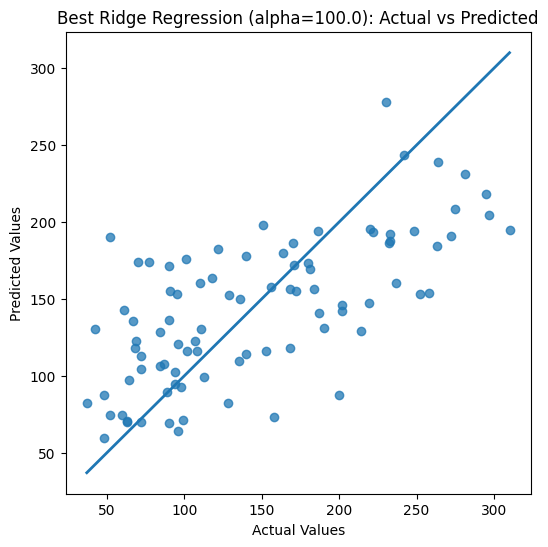

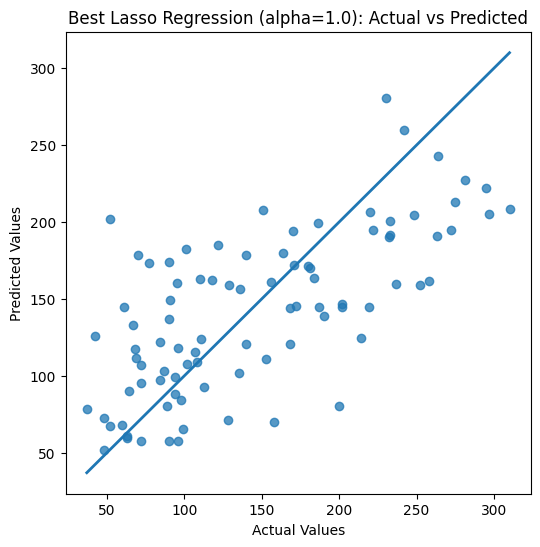

In [15]:

# Predicted vs actual plots for best Ridge and best Lasso
plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_ridge_pred, alpha=0.75)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linewidth=2)
plt.title(f'Best Ridge Regression (alpha={best_ridge_alpha}): Actual vs Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_lasso_pred, alpha=0.75)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linewidth=2)
plt.title(f'Best Lasso Regression (alpha={best_lasso_alpha}): Actual vs Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()


### How Alpha Influenced the Models
- With **smaller alpha values**, the regularization penalty was weak, so the model stayed close to ordinary linear regression.
- With **moderate alpha values**, the model became more stable and generalization slightly improved.
- With **very large alpha values**, the penalty became too strong and the models started to underfit.

In this lab, **Ridge** stayed relatively stable across alpha values, while **Lasso** improved at a moderate alpha but then dropped sharply when alpha became too large. Lasso also reduced the number of active coefficients as alpha increased.


## Step 6: Model Comparison and Analysis

To compare the final models fairly, I summarized the testing results below.


In [16]:

# Build a final comparison table using test-set performance
final_comparison = pd.DataFrame([
    {
        'Model': 'Simple Linear Regression (BMI only)',
        **simple_test_metrics
    },
    {
        'Model': 'Multiple Linear Regression',
        **multiple_test_metrics
    },
    {
        'Model': 'Polynomial Regression (Degree 2)',
        **regression_metrics(y_test, poly_deg2_pred)
    },
    {
        'Model': 'Polynomial Regression (Degree 3)',
        **regression_metrics(y_test, poly_deg3_pred)
    },
    {
        'Model': f'Ridge Regression (alpha={best_ridge_alpha})',
        **regression_metrics(y_test, best_ridge_pred)
    },
    {
        'Model': f'Lasso Regression (alpha={best_lasso_alpha})',
        **regression_metrics(y_test, best_lasso_pred)
    }
])

final_comparison = final_comparison.sort_values(by='RMSE').reset_index(drop=True)
display(final_comparison)


,Model,MAE,MSE,RMSE,R2
0,Lasso Regression (alpha=1.0),42.8030,"2,824.5681",53.1467,0.4669
1,Ridge Regression (alpha=100.0),43.2507,"2,858.2243",53.4624,0.4605
2,Multiple Linear Regression,42.7941,"2,900.1936",53.8534,0.4526
3,Polynomial Regression (Degree 2),43.5817,"3,096.0283",55.6420,0.4156
4,Simple Linear Regression (BMI only),52.2600,"4,061.8259",63.7325,0.2334
5,Polynomial Regression (Degree 3),164.8539,"82,446.0479",287.1342,-14.5613


## Final Discussion

### 1. How well each model performed
- The **simple linear regression** model was useful as a baseline, but it had limited predictive power because it relied on only one feature.
- The **multiple linear regression** model performed much better because it used all available features.
- The **degree 2 polynomial model** captured some additional relationships, but it did not clearly outperform the best linear-based models.
- The **degree 3 polynomial model** overfit badly, showing that a more complex model is not always a better model.
- **Ridge regression** produced stable results and performed slightly better than standard multiple regression.
- **Lasso regression** with a moderate alpha value performed the best overall in this notebook and also simplified the model by shrinking some coefficients to zero.

### 2. Which models handled overfitting or improved performance
The strongest overfitting appeared in the **degree 3 polynomial regression** model. Its training performance was extremely strong, but its testing performance dropped sharply. In contrast, **Ridge** and **Lasso** controlled model complexity and helped the model generalize more effectively.

### 3. Insights gained about the Diabetes dataset
- **BMI** had the strongest individual relationship with disease progression in this dataset.
- Using multiple features clearly improved performance compared with using only one feature.
- Regularization was valuable because it improved model stability and slightly improved testing performance.
- More complexity does not automatically lead to better prediction quality. Choosing the right model requires balancing fit and generalization.

## Conclusion
This lab showed the trade-off between model simplicity, flexibility, and generalization. Multiple regression provided a strong baseline, polynomial regression demonstrated the risk of overfitting, and regularization helped improve model robustness. Overall, the results showed that **moderately regularized linear models** worked best for this dataset.


## Repository Submission Note
The completed notebook and README for this lab are intended to be uploaded to the following public GitHub repository:

**https://github.com/Sandeep271/Lab-4-Regression-Analysis-with-Regularization-Techniques**

That repository should include:
- `MSCS_634_Lab_4_Regression_Analysis.ipynb`
- `README.md`
